In [ ]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

In [ ]:
sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [ ]:
sample_images.shape
# We need to change the channel infront of height and weight

torch.Size([2, 427, 640, 3])

In [ ]:
sample_images_permuted = sample_images.permute(0,3,1,2)

In [ ]:
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

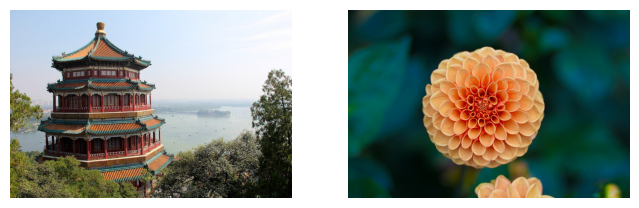

In [ ]:
import matplotlib.pyplot as plt

def plot_image(image):
  plt.imshow(image.permute(1,2,0))
  plt.axis('off')

plt.figure(figsize = (8,6))
for index, image in enumerate(sample_images_permuted):
  plt.subplot(1, 2, index + 1)
  plot_image(image)


In [ ]:
import torchvision
import torchvision.transforms.v2 as T

cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape


torch.Size([2, 3, 70, 120])

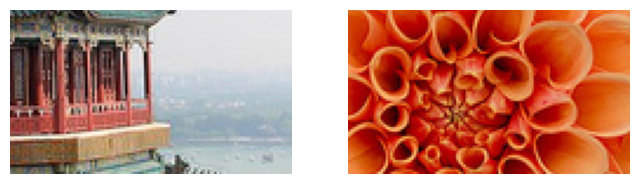

In [ ]:
plt.figure(figsize = (8,6))
for index, image in enumerate(cropped_images):
  plt.subplot(1, 2, index + 1)
  plot_image(image)

  # we cropped the images using centercrop

In [ ]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 7)
fmaps = conv_layer(cropped_images)

In [ ]:
fmaps.shape

torch.Size([2, 32, 64, 114])

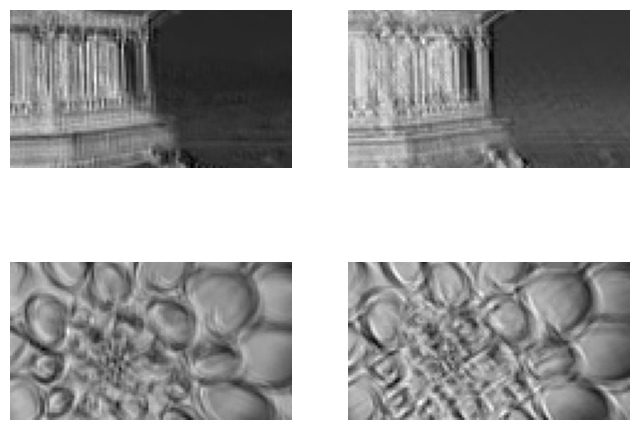

In [ ]:
plt.figure(figsize = (8,6))
for img_idx in (0,1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx + 1)
    plt.imshow(fmaps[img_idx, fmap_idx].detach(), cmap = 'gray')
    plt.axis('off')

plt.show()

# COnvolutional layers gives feature maps which acts like spatial detection like here it detected the edges

In [ ]:
conv_layer = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 7, padding = "same")
fmaps2 = conv_layer(cropped_images)

In [ ]:
fmaps2.shape
# Same padding gives exactly the same size we gave as input due

torch.Size([2, 32, 70, 120])

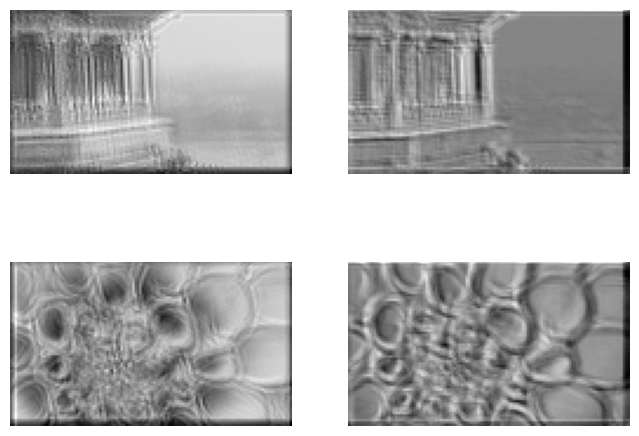

In [ ]:
plt.figure(figsize = (8,6))
for img_idx in (0,1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx + 1)
    plt.imshow(fmaps2[img_idx, fmap_idx].detach(), cmap = 'gray')
    plt.axis('off')

plt.show()

In [ ]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
fmaps3 = conv_layer(cropped_images)
fmaps3.shape

# By using stride as 2 we reduce the image size to half which reduced in image quality

torch.Size([2, 32, 35, 60])

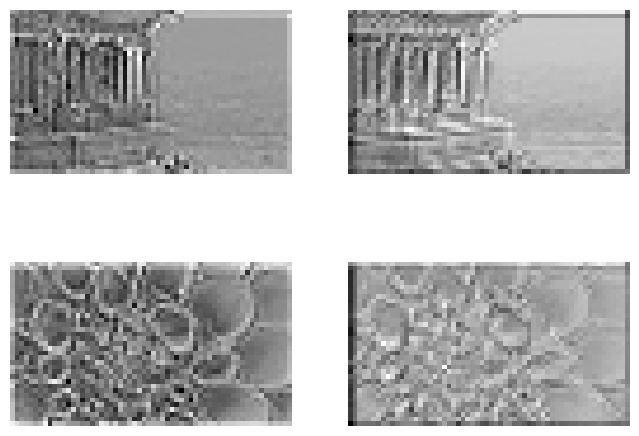

In [ ]:
plt.figure(figsize = (8,6))
for img_idx in (0,1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx + 1)
    plt.imshow(fmaps3[img_idx, fmap_idx].detach(), cmap = 'gray')
    plt.axis('off')

plt.show()

# See here there is loss in image quality

In [ ]:
conv_layer.weight.shape

torch.Size([32, 3, 7, 7])

In [ ]:
conv_layer.bias.shape

torch.Size([32])

In [ ]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
fmaps = F.conv2d(cropped_images, filters, biases, stride = 1, padding = "same")
# we can use torch functional function to manually set the weight and biases for the layers

In [ ]:
fmaps.shape

torch.Size([2, 2, 70, 120])

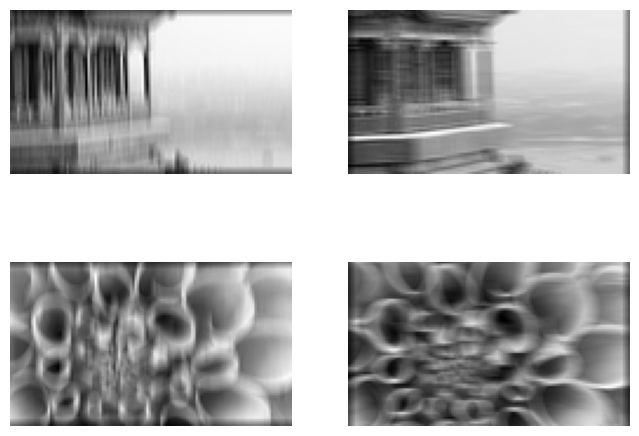

In [ ]:
plt.figure(figsize = (8,6))
filters = torch.zeros([2, 3, 7, 7])
filters[0, :, :, 3] = 1
filters[1, :, 3, :] = 1

fmaps = F.conv2d(cropped_images, filters, biases, stride = 1, padding = "same")
# we created a manual filter to implement vertical and horizontal blur in the middle of the images

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

# here both top and bottom of left images has blacked edges due to zero padding and we used vertical blur here and same for horizontal blur in right images has left and right side

In [ ]:
max_pool = nn.MaxPool2d(kernel_size = 2)

In [ ]:
output_max = max_pool(cropped_images)

In [ ]:
avg_pool = nn.AvgPool2d(kernel_size = 2)
output_avg = avg_pool(cropped_images)

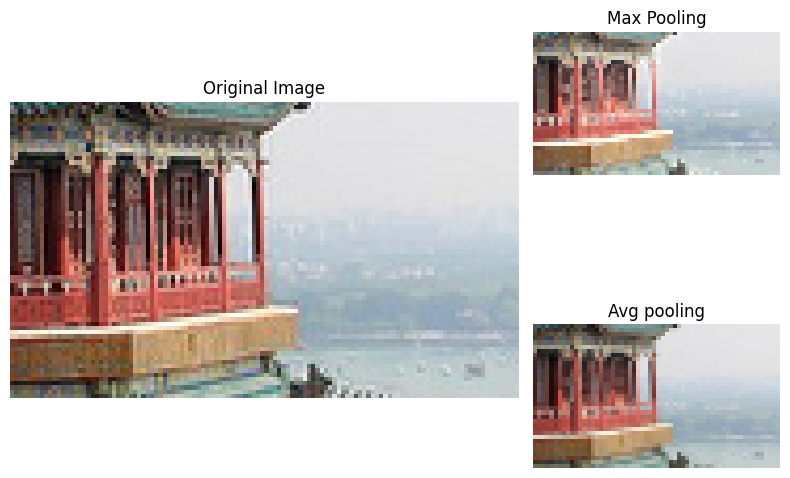

In [ ]:
fig = plt.figure(figsize = (8, 6))

ax1 = plt.subplot2grid((2, 3), (0,0), rowspan = 2, colspan = 2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title('Original Image')

ax2 = plt.subplot2grid((2,3), (0,2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title('Max Pooling')

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

# In Max Pooling the edges were detected more than in Avg pooling as it get the maximum value from an pooling layer
# In Avg Pooling the pixels were smooth as it averages the pixels in a kernel